In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import pickle, copy, random
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from scipy import stats
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.stats.multitest as multi

In [2]:
def to_day(di):
    if di >= 2:
        return "Day6"
    else:
        return "Day" + str(di + 1)

In [3]:
with open("loss_save.pkl", "rb") as f:
    loss_save = pickle.load(f)
with open("succ_fail_dec.pkl", "rb") as f:
    succ_fail_dec = pickle.load(f)

In [4]:
n_iter = 10
behs = ["Zone", "Lick", "Reward", "X", "Y"]

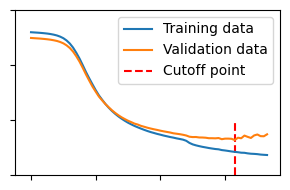

In [5]:
mi = 4
di = 2
i = 0
bi = 2
plt.figure(figsize=(3, 2))
loss = loss_save[mi, di, loss_save[mi, di, :, i, bi, 0] < np.inf, i, bi]
cutoff = loss[:, 2].argmin()
plt.plot(loss[:, 1], label="Training data", zorder=1)
plt.plot(loss[:, 2], label="Validation data", zorder=2)
plt.vlines(x=cutoff, ymin=0, ymax=0.1, linestyle="--", color="r", label="Cutoff point", zorder=0)
plt.legend()
plt.xlim(-5, 77)
plt.xticks([0, 20, 40, 60])
plt.ylim(0, 0.3)
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/fig7/fig7c.png")

In [6]:
indice = loss_save[:, :, :, :, :, 2].argmin(axis=2)
result = np.zeros((6, 3, n_iter, 5))
sf = np.zeros((6, 3, n_iter, 2))
for mi in range(6):
    for di in range(3):
        for i in range(n_iter):
            for bi in range(5):
                result[mi, di, i, bi] = loss_save[mi, di, indice[mi, di, i, bi], i, bi, 0]
            sf[mi, di, i, 0] = succ_fail_dec[mi][di][i][indice[mi, di, i, 2]][0].mean()
            sf[mi, di, i, 1] = succ_fail_dec[mi][di][i][indice[mi, di, i, 2]][1].mean()
result = np.mean(result, axis=2)

Day1: 0.2055 ± 0.0180
Day2: 0.1725 ± 0.0061
Day6: 0.1363 ± 0.0177
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day  4.1447 2.0000 10.0000 0.0489

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2   -0.033 0.2953 -0.0881 0.0221  False
  Day1   Day6  -0.0691 0.0138 -0.1242 -0.014   True
  Day2   Day6  -0.0362 0.2354 -0.0913 0.0189  False
---------------------------------------------------


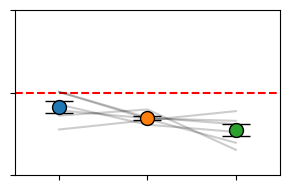

Day1: 0.1544 ± 0.0140
Day2: 0.1536 ± 0.0033
Day6: 0.1655 ± 0.0096
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day  0.5213 2.0000 10.0000 0.6091

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2  -0.0008 0.9984 -0.0375  0.036  False
  Day1   Day6   0.0112 0.7141 -0.0256 0.0479  False
  Day2   Day6    0.012 0.6815 -0.0248 0.0487  False
---------------------------------------------------


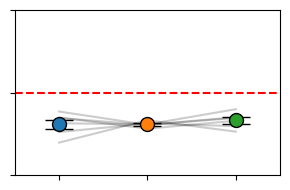

Day1: 0.1541 ± 0.0244
Day2: 0.1378 ± 0.0230
Day6: 0.1012 ± 0.0153
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day  2.5922 2.0000 10.0000 0.1239

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2  -0.0164 0.8508 -0.0945 0.0618  False
  Day1   Day6  -0.0529 0.2173 -0.1311 0.0253  False
  Day2   Day6  -0.0365 0.4639 -0.1147 0.0417  False
---------------------------------------------------


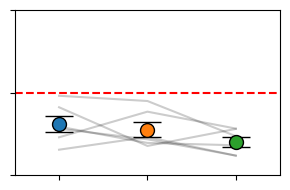

Day1: 0.1653 ± 0.0126
Day2: 0.1360 ± 0.0089
Day6: 0.1443 ± 0.0186
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day  1.5902 2.0000 10.0000 0.2514

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2  -0.0293 0.3252 -0.0806 0.0219  False
  Day1   Day6   -0.021 0.5504 -0.0722 0.0303  False
  Day2   Day6   0.0083 0.9068 -0.0429 0.0596  False
---------------------------------------------------


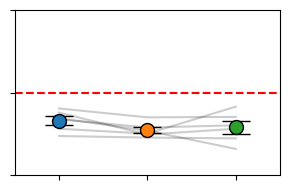

Day1: 0.2349 ± 0.0105
Day2: 0.2095 ± 0.0078
Day6: 0.2014 ± 0.0146
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day  1.9797 2.0000 10.0000 0.1887

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2  -0.0255 0.2803 -0.0671 0.0161  False
  Day1   Day6  -0.0335 0.1251 -0.0751 0.0081  False
  Day2   Day6  -0.0081  0.871 -0.0497 0.0336  False
---------------------------------------------------


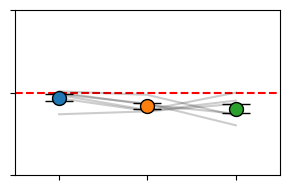

In [7]:
panels = ["e", "h", "f", "i", "j"]
for bi in range(5):
    plt.figure(figsize=(3, 2))
    plt.plot(result[:, :, bi].T, color="black", alpha=0.2, zorder=1)
    for di in range(3):
        y = result[:, di, bi].mean()
        yerr = stats.sem(result[:, di, bi])
        print("{}: {:.4f} ± {:.4f}".format(to_day(di), y, yerr))
        plt.errorbar(di, y=y, fmt="o", yerr=yerr, ecolor="black", markeredgecolor="black", color="C"+str(di), markersize=10, capsize=10, zorder=2)
    plt.xticks(np.arange(3))
    plt.xlim(-0.5, 2.5)
    plt.ylim(0, 0.5)
    plt.yticks([0, 0.25, 0.5])
    plt.hlines(y=0.25, xmin=-0.5, xmax=2.5, linestyle="--", color="r", zorder=0)
    plt.tick_params(labelleft=False, labelbottom=False)
    plt.tight_layout()
    plt.savefig("figures/fig7/fig7{}.png".format(panels[bi]))
    
    df = pd.DataFrame({
        "mouse": np.tile(np.arange(1, 7), 3),
        "loss": result[:, :, bi].T.reshape(-1),
        "day": np.repeat([to_day(di) for di in range(3)], 6),
    })
    print(AnovaRM(data=df, depvar="loss", subject="mouse", within=["day"]).fit())
    tukey = pairwise_tukeyhsd(endog=df['loss'],
                          groups=df['day'],
                          alpha=0.05)
    print(tukey)
    plt.show()

In [8]:
t_result = [stats.ttest_1samp(result[:, di, bi], 0.25) for bi in range(5) for di in range(3)]
t_val = [ti.statistic for ti in t_result]
p_val = [ti.pvalue for ti in t_result]
f_val = [ti.df for ti in t_result]
p_cor = multi.multipletests(p_val, alpha=0.05, method="bonferroni")[1]

print("one sample t-test with bonferroni correction")
for bi in range(5):
    print("({:<6}) Day1: t{}={:>8.4f}, p_cor={:.4f} | Day2: t{}={:>8.4f}, p_cor={:.4f} | Day6: t{}={:>8.4f}, p_cor={:.4f}".format(
        behs[bi], 
        f_val[bi*3], t_val[bi*3], p_cor[bi*3], 
        f_val[bi*3+1], t_val[bi*3+1], p_cor[bi*3+1], 
        f_val[bi*3+2], t_val[bi*3+2], p_cor[bi*3+2], 
    ))

one sample t-test with bonferroni correction
(Zone  ) Day1: t5= -2.4810, p_cor=0.8366 | Day2: t5=-12.6467, p_cor=0.0008 | Day6: t5= -6.4059, p_cor=0.0206
(Lick  ) Day1: t5= -6.8148, p_cor=0.0156 | Day2: t5=-28.8982, p_cor=0.0000 | Day6: t5= -8.8041, p_cor=0.0047
(Reward) Day1: t5= -3.9335, p_cor=0.1655 | Day2: t5= -4.8771, p_cor=0.0685 | Day6: t5= -9.7101, p_cor=0.0030
(X     ) Day1: t5= -6.7120, p_cor=0.0167 | Day2: t5=-12.8225, p_cor=0.0008 | Day6: t5= -5.6884, p_cor=0.0351
(Y     ) Day1: t5= -1.4305, p_cor=1.0000 | Day2: t5= -5.1730, p_cor=0.0532 | Day6: t5= -3.3334, p_cor=0.3105


Day1: 0.1709 ± 0.0501
Day2: 0.2474 ± 0.0486
Day6: 0.4623 ± 0.0534


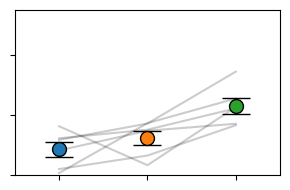

In [9]:
sf_rate = (sf[:, :, :, 1] - sf[:, :, :, 0]).mean(axis=2)
plt.figure(figsize=(3, 2))
plt.plot(sf_rate.T, c="k", alpha=0.2, zorder=1)
for di in range(3):
    y = sf_rate[:, di].mean()
    yerr = stats.sem(sf_rate[:, di])
    print("{}: {:.4f} ± {:.4f}".format(to_day(di), y, yerr))
    plt.errorbar(di, y=y, fmt="o", yerr=yerr, ecolor="black", markeredgecolor="black", color="C"+str(di), markersize=10, capsize=10, zorder=2)
plt.xticks(np.arange(3))
plt.xlim(-0.5, 2.5)
plt.ylim(0, 1.1)
plt.yticks([0, 0.4, 0.8])
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/fig7/fig7g.png")

In [10]:
df = pd.DataFrame({
    "mouse": np.tile(np.arange(1, 7), 3),
    "diff": sf_rate.T.reshape(-1),
    "day": np.repeat([to_day(di) for di in range(3)], 6),
})
print(AnovaRM(data=df, depvar="diff", subject="mouse", within=["day"]).fit())
tukey = pairwise_tukeyhsd(endog=df['diff'],
                        groups=df['day'],
                        alpha=0.05)
print(tukey)

              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day 10.7263 2.0000 10.0000 0.0032

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2   0.0765 0.5487 -0.1099  0.263  False
  Day1   Day6   0.2914 0.0028  0.1049 0.4779   True
  Day2   Day6   0.2149 0.0233  0.0284 0.4013   True
---------------------------------------------------
